# 长尾训练

In [ ]:
! tensorboard --logdir=E:\Github\LT-Uncertainty\output\results\test\log

^C


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets, models
import os

# 定义一些超参数
batch_size = 32
test_path = r'D:\BaiduNetdiskDownload\Remote_Sense_Datasets\HRSC\test'    # 替换为你的测试集路径
image_size=512
crop_size=448

# 1. 数据预处理
test_transform = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.CenterCrop((crop_size, crop_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

# 2. 加载数据集
test_dataset = datasets.ImageFolder(root=test_path, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. 加载预训练的ResNet18模型
model = models.resnet18(pretrained=False)
num_classes = len(test_dataset.classes)  # 计算类别数量
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 加载保存的模型权重
model_path = './output/models/HRSC/resnet18_model.pth'
model.load_state_dict(torch.load(model_path))

# 4. 使用GPU（如果有）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 5. 评估模型
model.eval()  # 设置模型为评估模式
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        print(labels,outputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0') tensor([[ 2.4079,  2.5240,  0.1894, -1.4025,  0.1344, -1.5008, -1.9083, -2.6482,
         -2.3984, -1.9938, -0.0610,  2.3360,  1.9878, -1.5222,  1.3376, -3.7216,
          0.9235, -1.5519],
        [ 2.6451,  2.8950, -0.5970, -0.2247, -1.0453, -1.3816, -1.4437, -1.6232,
         -3.1166, -2.5303, -0.1128,  1.8593,  2.8133, -2.0336,  0.9203, -2.4397,
          0.4120, -2.5795],
        [ 2.6648,  3.0190, -0.4162, -0.5554, -0.6341, -1.5849, -1.8170, -2.0850,
         -3.0432, -2.4390, -0.3896,  1.9938,  2.9449, -1.8507,  1.2109, -2.8342,
          0.6680, -2.4363],
        [-0.1205,  3.4635, -0.0854, -0.5067, -2.5944,  0.9683, -1.3625,  2.0842,
         -0.0914, -3.6837, -1.0264,  3.1508,  2.0298, -1.8270, -2.2840, -1.5314,
         -1.8436, -2.3513],
        [-0.5817,  3.5910,  0.1884, -0.9750, -2.9048,  0.7831, -1.0697,  1.6858,
          0.0567, -3.3420, -0

# 伽马函数单调性

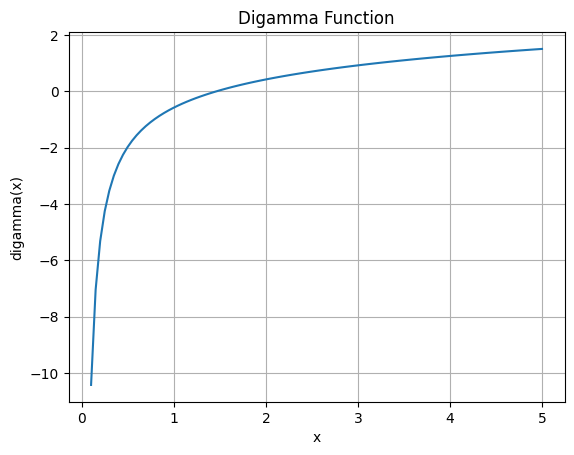

In [1]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(0.1, 5, 100)
y = torch.digamma(x)

plt.plot(x.numpy(), y.numpy())
plt.title("Digamma Function")
plt.xlabel("x")
plt.ylabel("digamma(x)")
plt.grid(True)
plt.show()


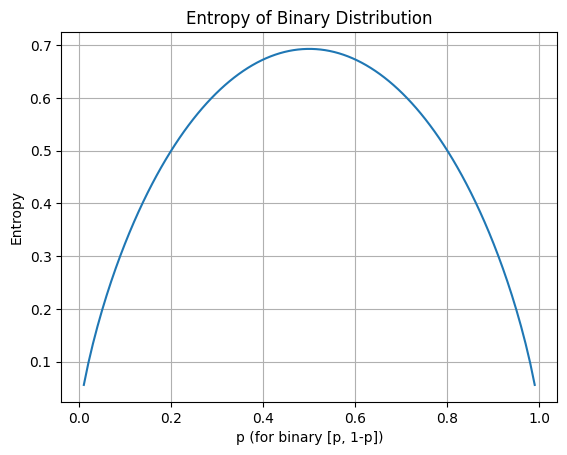

In [2]:
import torch
import matplotlib.pyplot as plt

def entropy(p):
    return -torch.sum(p * torch.log(p + 1e-10), dim=-1)

x = torch.linspace(0.01, 0.99, 100)
entropy_vals = entropy(torch.stack([x, 1 - x], dim=1))

plt.plot(x.numpy(), entropy_vals.numpy())
plt.xlabel('p (for binary [p, 1-p])')
plt.ylabel('Entropy')
plt.title('Entropy of Binary Distribution')
plt.grid(True)
plt.show()


# 分析不确定性的变化

## K/S和EU的关系

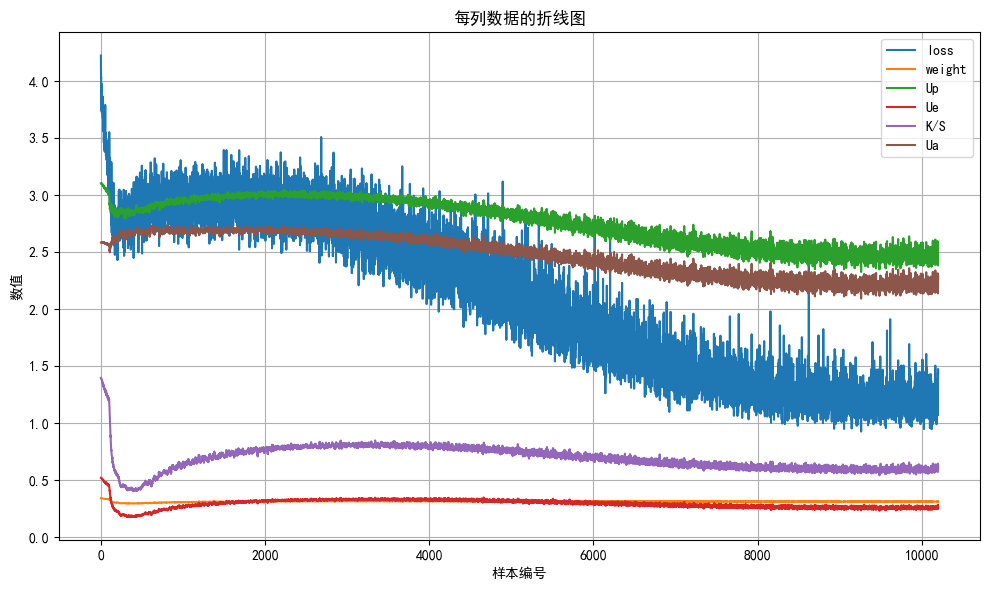

            loss    weight        Up        Ue       K/S        Ua
loss    1.000000  0.125438  0.937961  0.503004  0.542654  0.957342
weight  0.125438  1.000000  0.311553  0.861038  0.819612  0.092897
Up      0.937961  0.311553  1.000000  0.697760  0.735473  0.952671
Ue      0.503004  0.861038  0.697760  1.000000  0.992621  0.489220
K/S     0.542654  0.819612  0.735473  0.992621  1.000000  0.532565
Ua      0.957342  0.092897  0.952671  0.489220  0.532565  1.000000


In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取数据
file_path = r'E:\Github\LT-Uncertainty\output\FGSC\_reset50\trust_decomposition_warmup+cosine\results\loss.txt'  # 替换成你的实际路径
df = pd.read_csv(file_path, sep=' ', header=None)
df.columns = ['loss', 'weight', 'Up', 'Ue', 'K/S']
plot_columns = ['K/S','Ue']
df['Ua'] = df['Up'] - df['Ue']
# 2. 绘制折线图
# 设置中文字体为 SimHei，支持负号
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题
plt.figure(figsize=(10, 6))
for col in df.columns:
    # if col in plot_columns:
        plt.plot(df.index, df[col], label=col)

plt.xlabel('样本编号')
plt.ylabel('数值')
plt.title('每列数据的折线图')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
correlation_matrix = df.corr(method='spearman')
print(correlation_matrix)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置论文风格（Latex 字体 + 尺寸）
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12

plt.figure(figsize=(6, 4), dpi=300)
sns.regplot(x='Ue', y='K/S', data=df, scatter_kws={'s': 20}, line_kws={'color': 'red'})
plt.xlabel('Variable A')
plt.ylabel('Variable B')
plt.title('Relationship between A and B')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig('./figure/correlation_plot.png', dpi=300)
plt.show()


## 类别数量和不确定性的关系
需要记录label，batch 1
label、count、Ue、Ua、loss、K/S
resnet50/18 FGSC 100 30min

# 分析Evalution

In [30]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 

In [33]:
train_result = r"E:\Github\LT-Uncertainty\output\FGSC\_reset50\trust_decomposition_warmup+cosine\results\train_results.csv"
test_result = r"E:\Github\LT-Uncertainty\output\FGSC\_reset50\trust_decomposition_warmup+cosine\results\test_results.csv"
df_train = pd.read_csv(train_result)
df_test = pd.read_csv(test_result)

In [34]:
import pandas as pd

def summarize_by_label(df):
    # 分组聚合
    grouped = df.groupby('label').agg(
        count=('label', 'count'),
        accuracy=('correct', lambda x: x.sum() / len(x)),
        mean_Up=('Up', 'mean'),
        mean_Ue=('Ue', 'mean'),
        mean_Ua=('Ua', 'mean'),
        mean_Ks=('K/s', 'mean')
    ).reset_index()

    return grouped

# 假设 df 已经加载
summary_train = summarize_by_label(df_train)
summary_test = summarize_by_label(df_test)
print(summary_train)


    label  count  accuracy   mean_Up   mean_Ue   mean_Ua   mean_Ks
0       0    387  0.997416  2.131750  0.207128  1.924622  0.515668
1       1    132  1.000000  2.281358  0.227599  2.053759  0.566750
2       2    190  1.000000  2.173029  0.210557  1.962472  0.524113
3       3     17  1.000000  2.932954  0.332843  2.600112  0.826214
4       4    114  0.991228  2.510248  0.263028  2.247220  0.655044
5       5    180  1.000000  2.643070  0.287682  2.355388  0.717997
6       6     81  0.987654  2.573408  0.271827  2.301581  0.676334
7       7     58  1.000000  2.731542  0.297398  2.434143  0.740251
8       8     96  1.000000  2.315056  0.228861  2.086195  0.569017
9       9    274  0.992701  2.553456  0.270251  2.283205  0.673552
10     10    132  1.000000  2.644757  0.285892  2.358865  0.712582
11     11     82  0.987805  2.893111  0.333559  2.559552  0.831256
12     12    434  0.993088  1.981222  0.187409  1.793813  0.466232
13     13     70  0.942857  2.862634  0.327686  2.534949  0.81

In [321]:
summary_train.corr(method='spearman')

,label,count,accuracy,mean_Up,mean_Ue,mean_Ua,mean_Ks,test_acc
label,1.000000,-0.221453,-0.090563,0.199605,0.215415,0.200593,0.215415,-0.020756
count,-0.221453,1.000000,-0.098249,-0.685616,-0.665349,-0.701434,-0.665349,-0.019530
accuracy,-0.090563,-0.098249,1.000000,-0.187672,-0.212768,-0.180034,-0.212768,0.396173
mean_Up,0.199605,-0.685616,-0.187672,1.000000,0.996047,0.998024,0.996047,-0.450704
mean_Ue,0.215415,-0.665349,-0.212768,0.996047,1.000000,0.994071,1.000000,-0.467507
mean_Ua,0.200593,-0.701434,-0.180034,0.998024,0.994071,1.000000,0.994071,-0.425006
mean_Ks,0.215415,-0.665349,-0.212768,0.996047,1.000000,0.994071,1.000000,-0.467507
test_acc,-0.020756,-0.019530,0.396173,-0.450704,-0.467507,-0.425006,-0.467507,1.000000


In [322]:
# 只保留数值列进行相关性分析
# summar = summary_train
# summar['test_acc'] = summary_test['accuracy']
epoch = 4
b = 102
correlation_matrix = df_test.iloc[b*epoch:b*(epoch+1)].corr(method='spearman')
print(correlation_matrix)
epoch+=1


            loss    weight        Up        Ue       K/S        Ua
loss    1.000000 -0.043884  0.200129  0.029839  0.059954  0.218483
weight -0.043884  1.000000  0.041374  0.963970  0.857745 -0.201565
Up      0.200129  0.041374  1.000000  0.263991  0.104908  0.959028
Ue      0.029839  0.963970  0.263991  1.000000  0.842738  0.021990
K/S     0.059954  0.857745  0.104908  0.842738  1.000000 -0.116081
Ua      0.218483 -0.201565  0.959028  0.021990 -0.116081  1.000000


In [ ]:
a = []
epoch = 0
b = 102
while(b*(epoch+1)<=df.shape[0]):
    correlation_matrix = df.iloc[b*epoch:b*(epoch+1)].corr(method='spearman')
    a.append(correlation_matrix['Ue']['count'])
    epoch += 1
plt.figure()
plt.scatter(range(len(a)),a)
plt.show()

In [311]:
from scipy.stats import pearsonr,spearmanr

r, p = spearmanr(summar['mean_Ue'], summar['count'])
print(f"相关系数 r: {r:.2f}, p值: {p:.4f}")


相关系数 r: -0.67, p值: 0.0005


In [309]:
summar

,label,count,accuracy,mean_Up,mean_Ue,mean_Ua,mean_Ks,test_acc
0,0,387,0.997416,2.131750,0.207128,1.924622,0.515668,0.804124
1,1,132,1.000000,2.281358,0.227599,2.053759,0.566750,0.852941
2,2,190,1.000000,2.173029,0.210557,1.962472,0.524113,0.812500
3,3,17,1.000000,2.932954,0.332843,2.600112,0.826214,0.900000
4,4,114,0.991228,2.510248,0.263028,2.247220,0.655044,0.862069
5,5,180,1.000000,2.643070,0.287682,2.355388,0.717997,0.755556
6,6,81,0.987654,2.573408,0.271827,2.301581,0.676334,0.578947
7,7,58,1.000000,2.731542,0.297398,2.434143,0.740251,0.857143
8,8,96,1.000000,2.315056,0.228861,2.086195,0.569017,0.958333
9,9,274,0.992701,2.553456,0.270251,2.283205,0.673552,0.652174


# ACC格式化
从output中提取头尾类的正确率

In [57]:
# 获取对应数据的dict
def get_class2label(dataset_name:str):
    if dataset_name == 'dota':
        DataLabel2num = {14: 28068, 2: 26126, 11: 16969, 12: 7971, 9: 5983, 4: 5029, 6: 2367, 7: 2047, 5: 1736, 10: 630, 1: 515, 0: 415, 13: 399, 3: 326, 8: 325}
        class2label={
            "Baseball-diamond": 0,
            "Basketball-court": 1,
            "Bridge": 2,
            "Ground-track-field": 3,
            "Harbor": 4,
            "Helicopter": 5,
            "Large-Vehicle": 6,
            "Plane": 7,
            "Roundabout": 8,
            "Ship": 9,
            "Small-Vehicle": 10,
            "Soccer-ball-field": 11,
            "Swimming-Pool": 13,
            "Storage-Tank": 12,
            "Tennis-court": 14,
            }
        return DataLabel2num
    
    elif dataset_name == 'dior':
        DataLabel2num = {5: 27290, 10: 13713, 8: 4906, 7: 3053, 12: 2384, 3: 2369, 11: 2365, 0: 1892, 14: 1363, 4: 1336, 2: 1150, 17: 1080, 13: 1076, 1: 661, 15: 649, 18: 610, 6: 595, 16: 512, 19: 511, 9: 502}
        class2label={
            "Ship": 13,
            "Vehicle": 18,
            "Tennis court": 16,
            "Storage tank": 15,
            "Baseball field": 2,
            "Harbor": 11,
            "Windmill": 19,
            "Airplane": 0,
            "Bridge": 4,
            "Overpass": 12,
            "Ground track field": 10,
            "Expressway-Service area": 7,
            "Basketballcourt": 3,
            "Airport": 1,
            "Chimney": 5,
            "Expressway-toll-station": 8,
            "Stadium": 14,
            "Dam": 6,
            "Golf field": 9,
            "Train station": 17
            }
        return DataLabel2num
    
    elif dataset_name == 'fgsc23':
        real_label_to_data_label = {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '3': 16, '4': 17, '5': 18, '6': 19, '7': 20, '8': 21, '9': 22}
        DataLabel2num = {12: 434, 0: 387, 9: 274, 17: 236, 19: 234, 2: 190, 5: 180, 1: 132, 10: 132, 21: 123, 4: 114, 8: 96, 16: 86, 11: 82, 6: 81, 14: 74, 18: 72, 22: 71, 13: 70, 20: 70, 7: 58, 15: 43, 3: 17}

        label2class={
            0:"non-ship",
            1:"air carrier",
            2:"destroyer",
            3:"landing craft",
            4:"frigate",
            5:"amphibious transport dock",
            6:"cruiser",
            7:"Tarawa-class amphibious assault ship",
            8:"amphibious assault ship",
            9:"command ship",
            10:"submarine",
            11:"medical ship",
            12:"combat boat",
            13:"auxiliary ship",
            14:"container ship",
            15:"car carrier",
            16:"hovercraft",
            17:"bulk carrier",
            18:"oil tanker",
            19:"fishing boat",
            20:"passenger ship",
            21:"liquefied gas ship",
            22:"barge"}
        class2label = {value: key for key, value in label2class.items()}
        return DataLabel2num
    else:
        raise ValueError(f"input dataset_name error: {dataset_name}")

In [58]:
DataLabel2num = get_class2label(dataset_name='fgsc23')
fgsc23_sorted_dict = dict(sorted(DataLabel2num.items(), key=lambda item: item[1], reverse=True))
DataLabel2num = get_class2label(dataset_name='dior')
dior_sorted_dict = dict(sorted(DataLabel2num.items(), key=lambda item: item[1], reverse=True))
DataLabel2num = get_class2label(dataset_name='dota')
dota_sorted_dict = dict(sorted(DataLabel2num.items(), key=lambda item: item[1], reverse=True))

In [65]:
import re
import pandas as pd
import numpy as np
def head_tail_AvgAcc(flie_path, n, sorted_dict):
    all_epochs_class_accuracy = []

    current_epoch = None
    current_class_accuracy = {}

    with open(flie_path, 'r') as f:
        for line in f:
            line = line.strip()

            # 提取 Epoch 编号
            epoch_match = re.match(r'Epoch (\d+)', line)
            if epoch_match:
                if current_epoch is not None and current_class_accuracy:
                    all_epochs_class_accuracy.append((current_epoch, current_class_accuracy))
                    current_class_accuracy = {}
                current_epoch = int(epoch_match.group(1))

            # 提取 Class Accuracy
            class_match = re.match(r'Class (\d+) Accuracy: ([\d.]+)%', line)
            if class_match:
                class_id = int(class_match.group(1))
                accuracy = float(class_match.group(2))
                current_class_accuracy[class_id] = accuracy

        # 加入最后一个 Epoch 的数据
        if current_epoch is not None and current_class_accuracy:
            all_epochs_class_accuracy.append((current_epoch, current_class_accuracy))

    # 转换为 DataFrame
    df = pd.DataFrame(
        [{**{'Epoch': epoch}, **acc_dict} for epoch, acc_dict in all_epochs_class_accuracy]
    )

    # 设置 Epoch 为索引（可选）
    df.set_index('Epoch', inplace=True)
    acc_list = df.iloc[-1].to_list()
    data = dict()
    for dl,_ in sorted_dict.items():
        data[dl] = acc_list[dl]
    # 打印label：Acc
    print(data)
    # n = 7  # 前 n 个
    values = [v for i, (k, v) in enumerate(data.items())]
    head_avg = sum(values[:n])/n
    tail_avg = sum(values[n:])/(len(values)-n)
    print(values[:n])
    print(values[n:])
    return head_avg, tail_avg

In [61]:
# fgsc
flie_path = r"E:\Github\LT-Uncertainty\output\FGSC\_reset50\v2\trust_smooth_warmup+cosine7-8\results\results.txt"
head_avg, tail_avg = head_tail_AvgAcc(flie_path,7,fgsc23_sorted_dict)
print(head_avg, tail_avg)

{12: 86.11, 0: 80.41, 9: 66.67, 17: 96.61, 19: 86.44, 2: 85.42, 5: 62.22, 1: 79.41, 10: 66.67, 21: 83.87, 4: 82.76, 8: 100.0, 16: 77.27, 11: 60.0, 6: 68.42, 14: 100.0, 18: 66.67, 22: 72.22, 13: 44.44, 20: 77.78, 7: 85.71, 15: 100.0, 3: 100.0}
80.55428571428571 79.07625


In [69]:
# dior
flie_path = r"E:\Github\LT-Uncertainty\output\dior\_efficientnet_b0\v2\trust_smooth_warmup+cosine7-12\results\results.txt"
head_avg, tail_avg = head_tail_AvgAcc(flie_path,8,dior_sorted_dict)
print(head_avg, tail_avg)

{5: 90.59, 10: 97.39, 8: 94.78, 7: 90.84, 12: 90.88, 3: 79.11, 11: 98.33, 0: 89.34, 14: 74.04, 4: 73.73, 2: 93.46, 17: 92.9, 13: 95.11, 1: 92.64, 15: 84.79, 18: 68.31, 6: 79.49, 16: 74.86, 19: 96.17, 9: 89.98}
[90.59, 97.39, 94.78, 90.84, 90.88, 79.11, 98.33, 89.34]
[74.04, 73.73, 93.46, 92.9, 95.11, 92.64, 84.79, 68.31, 79.49, 74.86, 96.17, 89.98]
91.40750000000001 84.62333333333333


In [73]:
# dota
flie_path = r"E:\Github\LT-Uncertainty\output\DOTA\_resnet50\v2\trust_smooth_warmup+cosine7-17-w2\results\results.txt"
head_avg, tail_avg = head_tail_AvgAcc(flie_path,6,dota_sorted_dict)
print(head_avg, tail_avg)

{14: 97.32, 2: 96.62, 11: 93.39, 12: 98.74, 9: 94.98, 4: 96.5, 6: 94.21, 7: 87.07, 5: 86.14, 10: 49.32, 1: 84.09, 0: 92.52, 13: 74.86, 3: 81.05, 8: 87.5}
[97.32, 96.62, 93.39, 98.74, 94.98, 96.5]
[94.21, 87.07, 86.14, 49.32, 84.09, 92.52, 74.86, 81.05, 87.5]
96.25833333333333 81.86222222222221
